## Data pre-pration

### 3.1 Handling Hidden Missing Values

In the Adult Income dataset, missing values are not stored as standard null values. Instead, they appear as `?`, mainly in the categorical columns `workclass`, `occupation`, and `native.country`.

I considered three possible approaches: dropping rows, imputing with the mode, or creating an explicit `Unknown` category. I decided to use `Unknown` for these categorical missing values. This choice keeps all observations, avoids forcing missing cases into the most frequent category, and makes the missingness visible for later interpretation.

This decision is also consistent with my earlier findings and related-work review. In one of the reviewed studies, dropping missing rows was a limitation because it could remove useful information. Since my project values transparency, reproducibility, and interpretability, using `Unknown` is a more suitable choice for this dataset.

In [1]:
from pathlib import Path

import pandas as pd

# Load the raw dataset
data_path = Path("../data/raw/adult.csv")
df = pd.read_csv(data_path)

# Columns with hidden missing values marked as '?'
hidden_missing_cols = ["workclass", "occupation", "native.country"]

print("Hidden missing values before handling:")
for col in hidden_missing_cols:
    print(f"{col}:", (df[col].astype(str).str.strip() == "?").sum())

# Replace '?' with an explicit category
for col in hidden_missing_cols:
    df[col] = df[col].astype(str).str.strip().replace("?", "Unknown")

print("\nUnique values after handling hidden missing values:")
for col in hidden_missing_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head())

display(df[hidden_missing_cols].head())

Hidden missing values before handling:
workclass: 1836
occupation: 1843
native.country: 583

Unique values after handling hidden missing values:

workclass:
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1298
Name: count, dtype: int64

occupation:
occupation
Prof-specialty     4140
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

native.country:
native.country
United-States    29170
Mexico             643
Unknown            583
Philippines        198
Germany            137
Name: count, dtype: int64


,workclass,occupation,native.country
0,Unknown,Unknown,United-States
1,Private,Exec-managerial,United-States
2,Unknown,Unknown,United-States
3,Private,Machine-op-inspct,United-States
4,Private,Prof-specialty,United-States


### 3.2 Removing Redundant Feature: `education`

The dataset contains two columns that encode exactly the same information about a person's education level: `education` (a string label, e.g. `Bachelors`, `HS-grad`) and `education.num` (an integer ranking from 1 to 16 that maps one-to-one onto those labels). Keeping both would introduce perfect redundancy—there is no new information in one that is not already in the other.

I keep `education.num` and drop `education`:

1. **It is already ordinal and numeric.** The numeric encoding preserves the natural ordering of education levels (e.g. `Preschool=1` < `Bachelors=13` < `Doctorate=16`), which is meaningful for both tree-based and linear models. Retaining the string version alongside it would only add noise and unnecessary columns after One-Hot Encoding.



In [2]:
# Verify the one-to-one mapping between education and education.num
print("Unique (education, education.num) pairs:", df.groupby("education")["education.num"].nunique().max())
print(df[["education", "education.num"]].drop_duplicates().sort_values("education.num").to_string(index=False))

# Drop the string version — education.num already encodes this information
df = df.drop(columns=["education"])
print("\n'education' column dropped. Remaining columns:", df.columns.tolist())

Unique (education, education.num) pairs: 1
   education  education.num
   Preschool              1
     1st-4th              2
     5th-6th              3
     7th-8th              4
         9th              5
        10th              6
        11th              7
        12th              8
     HS-grad              9
Some-college             10
   Assoc-voc             11
  Assoc-acdm             12
   Bachelors             13
     Masters             14
 Prof-school             15
   Doctorate             16

'education' column dropped. Remaining columns: ['age', 'workclass', 'fnlwgt', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


### 3.3 Dropping `fnlwgt`

`fnlwgt` is a census sampling weight that indicates how many people in the 
population a given record represents. It is assigned by the Census Bureau for 
survey calibration purposes and reflects nothing about the individual's personal 
or financial situation. For individual-level income prediction it is non-informative, 
and dropping it is consistent with standard practice on this dataset in the literature.

In [3]:
# Drop fnlwgt — census sampling weight, not an individual attribute
df = df.drop(columns=["fnlwgt"])

print("Columns after dropping fnlwgt:")
print(df.columns.tolist())
print(f"\nRemaining shape: {df.shape}")

Columns after dropping fnlwgt:
['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

Remaining shape: (32561, 13)


### 3.4 Outlier Analysis and Handling Decision

Before splitting the data, I examine the numeric features for extreme values to make an informed and justifiable decision about whether to remove or retain outliers.

**Decision: Keep outliers — no removal or capping applied.**

The justification is based on three arguments:

1. **These are real census records, not measurement errors.** Extreme values in `capital.gain` and `capital.loss` reflect actual financial transactions reported in the 1994 Census. Removing such rows would discard valid, real-world observations and introduce a systematic bias against high-income individuals.

2. **The preprocessing pipeline already handles skewness robustly.** I use **median imputation**, which is resistant to extreme values, and **StandardScaler**, which rescales all features to zero mean and unit variance. This reduces the disproportionate influence of outliers on linear models without removing any data.

3. **Tree-based models are outlier-insensitive by design.** Random Forest splits on thresholds, so the absolute magnitude of an outlier has no effect on how it is handled — a key consideration since Random Forest is one of the primary models in this project.

This approach is consistent with studies on this dataset that retain all observations and rely on robust preprocessing rather than data removal.

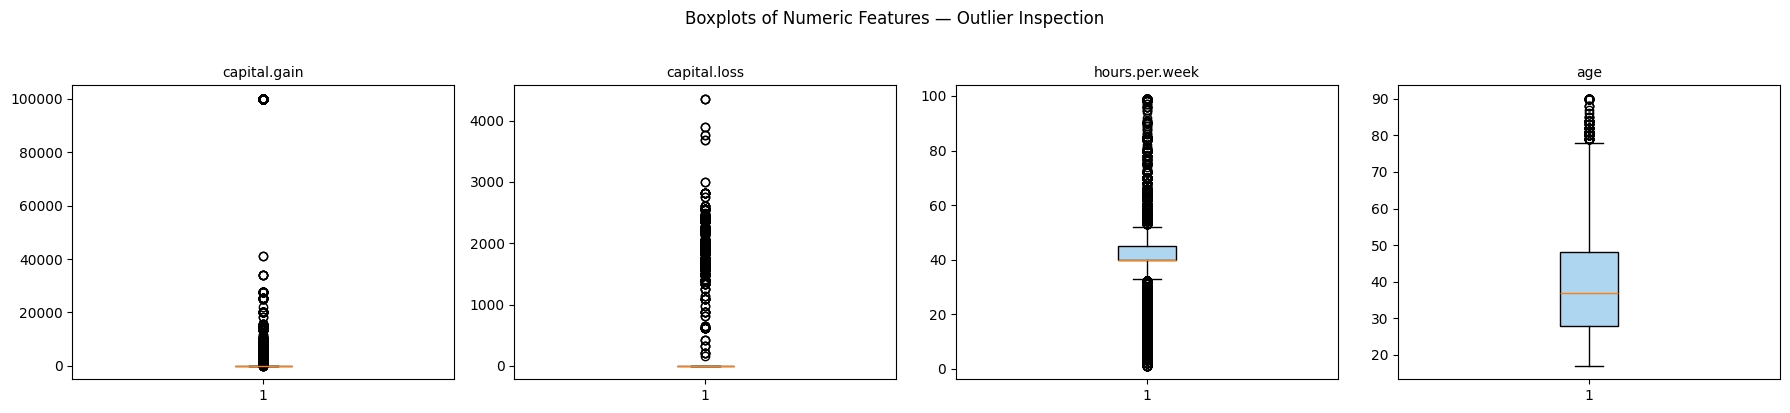

Outlier counts (IQR method, beyond 1.5×IQR):
  capital.gain: 2712 outliers (8.3% of data)
  capital.loss: 1519 outliers (4.7% of data)
  hours.per.week: 9008 outliers (27.7% of data)
  age: 143 outliers (0.4% of data)


In [6]:
import matplotlib.pyplot as plt

# Numeric columns to inspect for outliers
skewed_cols = ["capital.gain", "capital.loss", "hours.per.week", "age"]

fig, axes = plt.subplots(1, len(skewed_cols), figsize=(18, 4))

for ax, col in zip(axes, skewed_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#AED6F1"))
    ax.set_title(col, fontsize=10)

plt.suptitle("Boxplots of Numeric Features — Outlier Inspection", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# IQR-based outlier count per column
print("Outlier counts (IQR method, beyond 1.5×IQR):")
for col in skewed_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    pct = n_outliers / len(df) * 100
    print(f"  {col}: {n_outliers} outliers ({pct:.1f}% of data)")

### 3.5 Defining Target and Splitting the Data

After handling hidden missing values, removing the redundant `education` column, and confirming the outlier handling decision, the next step is to separate the target from the predictors and create train, validation, and test sets. I use a **stratified split** because the target variable `income` is imbalanced. This helps preserve the original class proportions across all subsets and makes later evaluation more reliable.

In [7]:
from sklearn.model_selection import train_test_split

# Define target and predictors
target_col = "income"
X = df.drop(columns=[target_col])
y = df[target_col]

# First split: training set and temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (22792, 12) (22792,)
Validation set: (4884, 12) (4884,)
Test set: (4885, 12) (4885,)


In [8]:
# Check class distribution in each split
split_distribution = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True) * 100).round(2),
    "val_%": (y_val.value_counts(normalize=True) * 100).round(2),
    "test_%": (y_test.value_counts(normalize=True) * 100).round(2),
}).fillna(0)

print("Income class distribution across splits (%):")
display(split_distribution)

Income class distribution across splits (%):


,train_%,val_%,test_%
income,,,
<=50K,75.92,75.92,75.93
>50K,24.08,24.08,24.07


In [9]:
# Save train/validation/test splits for reuse in other notebooks/files
split_dir = Path("../data/interim")
split_dir.mkdir(parents=True, exist_ok=True)

train_df = X_train.copy()
train_df[target_col] = y_train.values

val_df = X_val.copy()
val_df[target_col] = y_val.values

test_df = X_test.copy()
test_df[target_col] = y_test.values

train_path = split_dir / "train.csv"
val_path = split_dir / "val.csv"
test_path = split_dir / "test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved split files:")
print(train_path)
print(val_path)
print(test_path)

Saved split files:
../data/interim/train.csv
../data/interim/val.csv
../data/interim/test.csv


In [10]:
print("Train head:")
display(train_df.head())

print("Validation head:")
display(val_df.head())

print("Test head:")
display(test_df.head())

Train head:


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
24582,28,Private,9,Never-married,Sales,Own-child,White,Male,0,0,48,United-States,<=50K
10298,24,Self-emp-not-inc,4,Never-married,Farming-fishing,Own-child,White,Male,0,0,50,United-States,<=50K
16626,20,Private,10,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,35,United-States,<=50K
11039,70,Private,10,Widowed,Exec-managerial,Not-in-family,White,Female,0,0,12,United-States,<=50K
2535,44,Self-emp-inc,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,7688,0,45,United-States,>50K


Validation head:


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
14239,74,Private,6,Widowed,Other-service,Not-in-family,Black,Female,0,0,6,United-States,<=50K
22607,53,Federal-gov,9,Divorced,Tech-support,Unmarried,White,Male,0,0,40,United-States,<=50K
19069,32,Private,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,42,United-States,>50K
21156,48,Local-gov,11,Never-married,Protective-serv,Unmarried,White,Male,0,0,48,United-States,<=50K
17217,34,Self-emp-not-inc,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


Test head:


,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
16402,20,Private,9,Married-civ-spouse,Tech-support,Other-relative,White,Male,0,0,40,United-States,<=50K
21837,17,Private,7,Never-married,Sales,Own-child,White,Male,0,0,20,United-States,<=50K
9208,30,Private,7,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,0,0,40,United-States,<=50K
8996,28,Private,10,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
8782,42,Private,10,Divorced,Tech-support,Not-in-family,White,Female,0,0,40,United-States,<=50K


#### 3.5.1 I split the data into **70% training**, **15% validation**, and **15% test**. The training set will be used to fit preprocessing steps and train models, the validation set will support model selection and tuning, and the test set will remain untouched until the final evaluation.

### 3.6 Grouping Rare Categories Before Encoding

In Data Understanding, I found that some categorical columns, especially `native.country`, contain many rare categories. If I encode them directly, this can create a very sparse feature space and reduce interpretability. For that reason, I group rare categories **after the split** and base the grouping rule on the **training set only**.


In [11]:
# Group rare categories using training data only
rare_threshold = 0.01  # categories with less than 1% of training data will be grouped
group_cols = ["native.country"]

rare_category_maps = {}
for col in group_cols:
    freq = X_train[col].value_counts(normalize=True)
    rare_categories = freq[freq < rare_threshold].index.tolist()
    rare_category_maps[col] = rare_categories
    print(f"Rare categories in {col}:")
    print(rare_categories)

def group_rare_values(series, rare_values, other_label="Other"):
    return series.apply(lambda value: other_label if value in rare_values else value)

for col in group_cols:
    X_train[col] = group_rare_values(X_train[col], rare_category_maps[col])
    X_val[col] = group_rare_values(X_val[col], rare_category_maps[col])
    X_test[col] = group_rare_values(X_test[col], rare_category_maps[col])

print("\nValue counts in training set after grouping:")
for col in group_cols:
    print(f"\n{col}:")
    print(X_train[col].value_counts().head(10))

Rare categories in native.country:
['Philippines', 'Germany', 'Canada', 'Puerto-Rico', 'El-Salvador', 'Cuba', 'India', 'England', 'Jamaica', 'China', 'Dominican-Republic', 'Italy', 'South', 'Guatemala', 'Vietnam', 'Japan', 'Poland', 'Columbia', 'Taiwan', 'Iran', 'Haiti', 'Portugal', 'Nicaragua', 'Greece', 'Ecuador', 'Ireland', 'France', 'Peru', 'Cambodia', 'Trinadad&Tobago', 'Hong', 'Thailand', 'Honduras', 'Laos', 'Outlying-US(Guam-USVI-etc)', 'Yugoslavia', 'Scotland', 'Hungary']

Value counts in training set after grouping:

native.country:
native.country
United-States    20408
Other             1544
Mexico             436
Unknown            404
Name: count, dtype: int64


### 3.7 Building the Preprocessing Pipeline

After handling hidden missing values, splitting the data, and grouping rare categories, the next step is to prepare numeric and categorical features for modeling. I do this **after** those steps so that encoding reflects the cleaned and grouped feature values without causing data leakage.

For numeric variables, I use **median imputation** and **standard scaling**. Median imputation is a reasonable choice because several numeric features, such as `capital.gain` and `capital.loss`, are strongly skewed, so the median is more robust than the mean. Standard scaling is important for models such as Logistic Regression and SVM, which are sensitive to feature magnitude.

For categorical variables, I use **most-frequent imputation** together with **One-Hot Encoding**. One-Hot Encoding is appropriate because most categorical variables in this dataset are nominal rather than ordinal, and it allows models to use category information without imposing an artificial ranking. Even though I already replaced hidden missing values with `Unknown`, using an imputer in the pipeline makes the preprocessing more robust and reusable.

All preprocessing steps are fitted on the training set only, then applied to the validation and test sets. This keeps the evaluation procedure methodologically correct.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate numeric and categorical columns
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Numeric preprocessing: impute + scale
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing: impute + one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

# Fit on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Numeric columns: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical columns: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Processed train shape: (22792, 53)
Processed validation shape: (4884, 53)
Processed test shape: (4885, 53)


In [13]:
import joblib
from scipy import sparse

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save fitted preprocessor
joblib.dump(preprocessor, processed_dir / "preprocessor.joblib")

# Save processed feature matrices
sparse.save_npz(processed_dir / "X_train_processed.npz", X_train_processed)
sparse.save_npz(processed_dir / "X_val_processed.npz", X_val_processed)
sparse.save_npz(processed_dir / "X_test_processed.npz", X_test_processed)

# Save labels aligned with processed matrices
y_train.to_csv(processed_dir / "y_train.csv", index=False)
y_val.to_csv(processed_dir / "y_val.csv", index=False)
y_test.to_csv(processed_dir / "y_test.csv", index=False)

print("Saved preprocessing artifacts in:", processed_dir)

Saved preprocessing artifacts in: ../data/processed


### 3.7.1 Save Preprocessing Artifacts for Modeling

To avoid re-applying preprocessing in other notebooks, I save the fitted preprocessor and processed matrices here.